# Stroke Care Access Index Exploratory Data Analysis

| Variable | Type | Description | Notes |
|----------|------|--------|--------------------------|
| **fips** | Categorical | Five-digit Federal Information Processing Standards (FIPS) code uniquely identifying each county. | Covers NY (36), NJ (34), CT (09, using traditional 8-county boundaries, not the newer 9 planning regions) |
| **pcnt_insured** | Continous | Percent of adults insured in each county. | Left-skewed (skew ≈ -2.84), bounded near 100% with a tail of lower-insurance counties. Nearly uncorrelated with all supply-side variables (max 0.14). Note: will need to be inverted in SVI construction (low insurance = high vulnerability). Needs percentile-based treatment. |
| **hospitals_per_100k** | Continuos | Number of hospitals per 100,000 residents | Right-skewed (skew ≈ 1.77). Small/rural counties can show inflated rates due to tiny population denominators. Weakly correlated with most other access variables (Spearman ≈ 0.11 with stroke centers, -0.18 to -0.25 with PCPs/neurologists). Needs percentile-based treatment, not z-score.
| **hospital_beds_per_100k** | Continuous | Total hospital beds per 100,000 residents| Right-skewed (skew ≈ 1.32). Known outlier: Warren County, NY (36113) at 597 vs. sample mean 165, due to a regional hospital hub (Glens Falls Hospital) serving a multi-county catchment disproportionate to its own population. Moderately correlated with pcp_per_100k (0.52) and neurologists_per_100k (0.47).|
| **pcp_per_100k** | Continuous |Primary care physicians per 100,000 residents | Most normally distributed of the set (skew ≈ 0.59). Strongly correlated with neurologists_per_100k (0.73) — likely reflects general physician density; consider whether both should carry full independent weight in SCAI. |
| **neurologists_per_100k** | Continuous | Neurologists per 100,000 residents |Zero-inflated: 37/91 counties = 0. Highest skew (≈ 3.21). Strongly correlated with pcp_per_100k (0.73). Of 22 zero-stroke-center counties, 17 also have zero neurologists (plausible rural access pattern); 5 counties have a stroke center but zero counted neurologists (possible telestroke coverage or data source gap — worth a closer look if time allows). Needs percentile-based treatment.|
| **stroke_centers_per_100k** | Continuous | Designated stroke centers per 100,000 residents | Zero-inflated: 22/91 counties = 0 (skew ≈ 0.90, though understated given the zero-spike shape). In 29 counties, stroke_centers_per_100k exactly equals hospitals_per_100k because every hospital in that county happens to be a designated stroke center. Despite this, correlates only weakly with hospitals_per_100k overall (Spearman ≈ 0.11) since the pattern breaks down outside small counties. Needs percentile-based treatment.|

In [1]:
import pandas as pd
import sqlite3

In [8]:
con = sqlite3.connect("../data/stroke_burden.db")

In [9]:
scai_data = pd.read_sql("""
    SELECT c.fips, a.pcnt_insured,s.hospitals_per_100k, s.hospital_beds_per_100k, s.pcp_per_100k,
    s.neurologists_per_100k, s.stroke_centers_per_100k
    FROM counties c
    JOIN acs a USING (fips)
    JOIN scai s USING (fips)
""", con)

con.close()

In [10]:
scai_data

,fips,pcnt_insured,hospitals_per_100k,hospital_beds_per_100k,pcp_per_100k,neurologists_per_100k,stroke_centers_per_100k
0,36001,97.0,1.259486,384.457949,96.665512,13.224598,0.629743
1,36003,95.1,4.283206,147.770592,40.690453,0.000000,2.141603
2,36005,92.7,0.507071,210.651673,65.701880,6.229726,0.434632
3,36007,96.3,1.531128,257.229475,83.191279,4.083008,1.020752
4,36009,93.7,1.321510,266.945065,46.252858,1.321510,1.321510
...,...,...,...,...,...,...,...
86,09007,96.5,1.806032,112.576004,77.659382,4.816086,0.602011
87,09009,94.9,1.039601,210.807920,85.478280,16.287078,0.808578
88,09011,95.8,0.744829,157.531339,62.193224,3.351731,0.744829
89,09013,96.3,1.325328,96.748970,53.675798,1.325328,1.325328


## Checking types, values, and overlaps

In [13]:
# Fix fips dtype
scai_data['fips'] = scai_data['fips'].astype(str).str.zfill(5)

# Basic structure
print(scai_data.info())
print()
print(scai_data.describe())

# Nulls
print("\nNull counts:")
print(scai_data.isnull().sum())

# Zeros per column
print("\nZero counts per column:")
print((scai_data == 0).sum())

# How many counties per state (fips prefix)
scai_data['state_fips'] = scai_data['fips'].str[:2]
print("\nCounties per state:")
print(scai_data['state_fips'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91 entries, 0 to 90
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   fips                     91 non-null     object 
 1   pcnt_insured             91 non-null     float64
 2   hospitals_per_100k       91 non-null     float64
 3   hospital_beds_per_100k   91 non-null     float64
 4   pcp_per_100k             91 non-null     float64
 5   neurologists_per_100k    91 non-null     float64
 6   stroke_centers_per_100k  91 non-null     float64
 7   state_fips               91 non-null     object 
dtypes: float64(6), object(2)
memory usage: 5.8+ KB
None

       pcnt_insured  hospitals_per_100k  hospital_beds_per_100k  pcp_per_100k  \
count     91.000000           91.000000               91.000000     91.000000   
mean      94.838462            1.573227              164.693070     64.488949   
std        2.575214            1.308053               99.

In [4]:
#Checking same values in hospitals and stroke centers
match_mask = scai_data['hospitals_per_100k'] == scai_data['stroke_centers_per_100k']
print(f"Rows where hospitals == stroke_centers: {match_mask.sum()} / {len(scai_data)}")
print(scai_data.loc[match_mask, ['fips', 'hospitals_per_100k', 'stroke_centers_per_100k']])

Rows where hospitals == stroke_centers: 29 / 91
     fips  hospitals_per_100k  stroke_centers_per_100k
3   09011            0.744829                 0.744829
6   09013            1.325328                 1.325328
7   09015            1.707709                 1.707709
8   34001            1.084430                 1.084430
12  34009            1.057340                 1.057340
13  34011            0.647262                 0.647262
18  34021            1.022053                 1.022053
20  34025            0.774238                 0.774238
21  34027            0.773841                 0.773841
26  34037            0.683396                 0.683396
28  34041            1.791296                 1.791296
33  36009            1.321510                 1.321510
34  36011            1.341148                 1.341148
39  36021            1.649974                 1.649974
40  36023            2.173724                 2.173724
47  36037            1.723662                 1.723662
48  36039        

In [14]:
hospitals_per_100k = pd.read_csv('../data/scai_data/hospitals_per_100k_all.csv')
stroke_centers_per_100k = pd.read_csv('../data/scai_data/stroke_centers_per_100k.csv')

In [15]:
raw_compare = hospitals_per_100k[['fips', 'hospital_count']].merge(
    stroke_centers_per_100k[['fips', 'stroke_center_count']],
    on='fips',
    how='inner'
)

raw_compare['fips'] = raw_compare['fips'].astype(str).str.zfill(5)

equal_mask = raw_compare['hospital_count'] == raw_compare['stroke_center_count']
print(f"Rows where raw counts are equal: {equal_mask.sum()} / {len(raw_compare)}")
print(raw_compare.loc[equal_mask])

# And to see the actual magnitude of the counts (not just equal but how big)
print(raw_compare.loc[equal_mask].describe())

Rows where raw counts are equal: 29 / 91
     fips  hospital_count  stroke_center_count
4   36009             1.0                    1
5   36011             1.0                    1
10  36021             1.0                    1
11  36023             1.0                    1
18  36037             1.0                    1
19  36039             0.0                    0
20  36041             0.0                    0
25  36051             1.0                    1
31  36063             2.0                    2
39  36079             1.0                    1
41  36083             1.0                    1
42  36085             3.0                    3
49  36099             0.0                    0
53  36107             0.0                    0
54  36109             1.0                    1
56  36113             1.0                    1
57  36115             0.0                    0
58  36117             1.0                    1
62  34001             3.0                    3
66  34009          

stroke_centers_per_100k and hospitals_per_100k overlap on 29 fips. This is mostly in smaller counties where the # hospitals = # stroke centers. In other words, every hospital in these counties is designated as a stroke center. Including both in SCAI would be double-counting the same signal 

In [16]:
#outlier in hospital_beds_per_100k 
outlier_row = scai_data.loc[scai_data['hospital_beds_per_100k'].idxmax()]
print(outlier_row)

#top 5 highest
print("\nTop 5 hospital_beds_per_100k:")
print(scai_data.nlargest(5, 'hospital_beds_per_100k')[['fips', 'hospital_beds_per_100k']])

fips                            36113
pcnt_insured                     96.7
hospitals_per_100k           1.527487
hospital_beds_per_100k     597.247468
pcp_per_100k               116.089022
neurologists_per_100k        1.527487
stroke_centers_per_100k      1.527487
state_fips                         36
Name: 56, dtype: object

Top 5 hospital_beds_per_100k:
     fips  hospital_beds_per_100k
56  36113              597.247468
30  36061              475.196962
0   36001              384.457949
9   36019              367.113792
38  36077              351.595385


The counties that have a high hospital_beds_per_100k rate have hospitals that serve populations outside their own counties, so dividing by their own population inflates their score. Example that stands out is Warren County, which has a fairly large regional hospital (Glen Falls) that serves several surrouding regions. 

In [17]:
#Checking neurologists and stroke centers zero counts overlap
zero_neuro = set(scai_data.loc[scai_data['neurologists_per_100k'] == 0, 'fips'])
zero_stroke = set(scai_data.loc[scai_data['stroke_centers_per_100k'] == 0, 'fips'])

print(f"Zero neurologists: {len(zero_neuro)}")
print(f"Zero stroke centers: {len(zero_stroke)}")
print(f"Overlap: {len(zero_neuro & zero_stroke)}")
print(f"Neuro-zero but not stroke-zero: {sorted(zero_neuro - zero_stroke)}")
print(f"Stroke-zero but not neuro-zero: {sorted(zero_stroke - zero_neuro)}")

Zero neurologists: 22
Zero stroke centers: 22
Overlap: 17
Neuro-zero but not stroke-zero: ['36003', '36011', '36021', '36023', '36051']
Stroke-zero but not neuro-zero: ['36013', '36019', '36033', '36035', '36075']


A few counties have no neurologists but have designated stroke centers. Worth flagging since stroke centers typically need neurology coverage for certification. Maybe check raw neurologists data again.

## Distribution/Visualizations

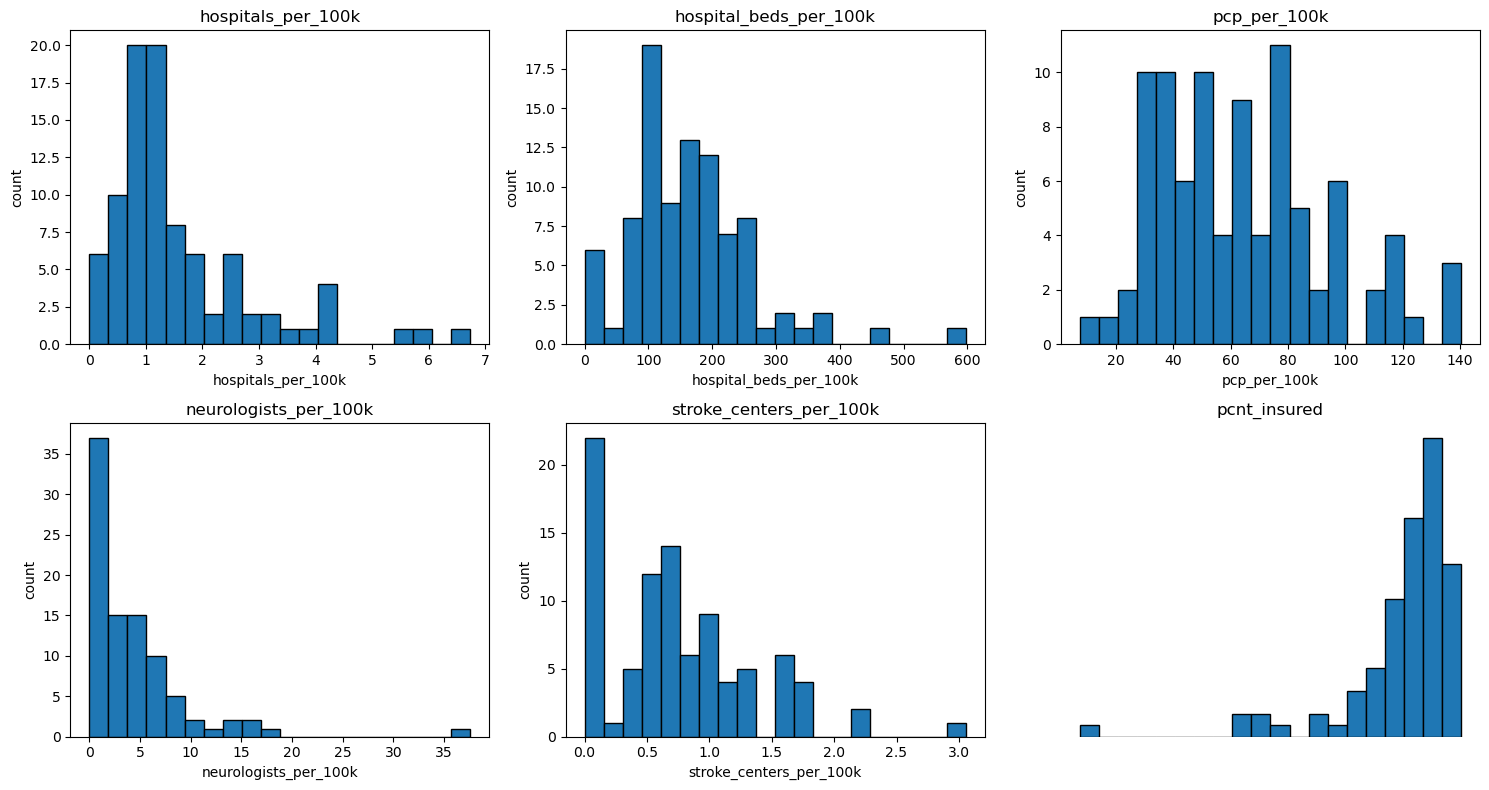

hospitals_per_100k         1.768705
hospital_beds_per_100k     1.315982
pcp_per_100k               0.592278
neurologists_per_100k      3.211727
stroke_centers_per_100k    0.901291
pcnt_insured              -2.839721
dtype: float64


In [19]:
import matplotlib.pyplot as plt

cols = ['hospitals_per_100k', 'hospital_beds_per_100k', 'pcp_per_100k', 
         'neurologists_per_100k', 'stroke_centers_per_100k', 'pcnt_insured']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].hist(scai_data[col], bins=20, edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('count')

axes[-1].axis('off')  # unused subplot
plt.tight_layout()
plt.show()

# Skewness to quantify what the histograms show
print(scai_data[cols].skew())

                         hospitals_per_100k  hospital_beds_per_100k  \
hospitals_per_100k                 1.000000                0.058155   
hospital_beds_per_100k             0.058155                1.000000   
pcp_per_100k                      -0.178206                0.519121   
neurologists_per_100k             -0.254634                0.465937   
stroke_centers_per_100k           -0.010252                0.266443   
pcnt_insured                      -0.041601                0.090685   

                         pcp_per_100k  neurologists_per_100k  \
hospitals_per_100k          -0.178206              -0.254634   
hospital_beds_per_100k       0.519121               0.465937   
pcp_per_100k                 1.000000               0.729453   
neurologists_per_100k        0.729453               1.000000   
stroke_centers_per_100k      0.098375               0.066793   
pcnt_insured                 0.052380               0.033584   

                         stroke_centers_per_100k  pcn

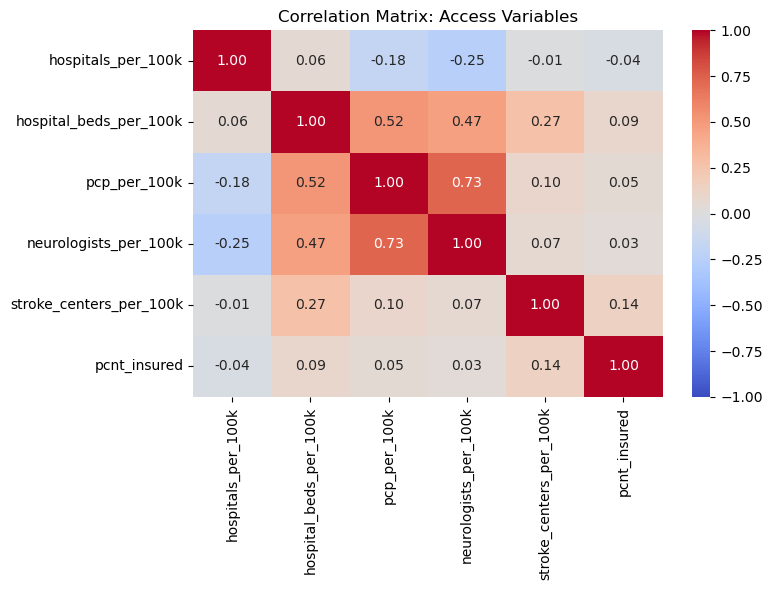

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['hospitals_per_100k', 'hospital_beds_per_100k', 'pcp_per_100k', 
         'neurologists_per_100k', 'stroke_centers_per_100k', 'pcnt_insured']

corr_matrix = scai_data[cols].corr()
print(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Matrix: Access Variables')
plt.tight_layout()
plt.show()

In [22]:
#Double Checking correlation with spearman
corr_spearman = scai_data[cols].corr(method='spearman')
print(corr_spearman)

                         hospitals_per_100k  hospital_beds_per_100k  \
hospitals_per_100k                 1.000000                0.150723   
hospital_beds_per_100k             0.150723                1.000000   
pcp_per_100k                      -0.185039                0.490560   
neurologists_per_100k             -0.348345                0.456154   
stroke_centers_per_100k            0.110083                0.307245   
pcnt_insured                       0.022899                0.038873   

                         pcp_per_100k  neurologists_per_100k  \
hospitals_per_100k          -0.185039              -0.348345   
hospital_beds_per_100k       0.490560               0.456154   
pcp_per_100k                 1.000000               0.797112   
neurologists_per_100k        0.797112               1.000000   
stroke_centers_per_100k      0.152938               0.238500   
pcnt_insured                 0.031577              -0.095157   

                         stroke_centers_per_100k  pcn

- Despite superficial overlap in a subset of counties, hospitals_per_100k and stroke_centers_per_100k are not redundant variables overall.
- pcp_per_100k and neurologists_per_100k show a strong correlation at .73
- hospitals_per_100k correlates negatively with pcp_per_100k (-0.18) and neurologists_per_100k (-0.25). Small rural counties can post a high hospitals_per_100k rate simply because their denominator (population) is tiny, even while physician staffing is low. 